# NASA POWER Data Download for Uganda

This notebook downloads meteorological and solar radiation data from the NASA POWER (Prediction of Worldwide Energy Resources) service for a grid of points covering Uganda. The data is essential for solar resource assessment and climate analysis across the country.

## Overview

The notebook performs the following tasks:
1. Creates a grid of points covering Uganda using a specified grid spacing
2. Filters points to include only those within Uganda's boundaries
3. Downloads multiple NASA POWER parameters for each point
4. Saves the data in a structured CSV format

## Requirements

### Software Requirements
- Python packages: numpy, pandas, geopandas, shapely, geopy
- Uganda shapefile (provided in the repository)
- SuSSE package (internal package for API interactions)

## Data Format

The downloaded data will be saved in a CSV file with the following structure:
- `latitude`: The latitude coordinate of the point
- `longitude`: The longitude coordinate of the point
- Additional columns for each NASA POWER parameter requested

In [5]:
# Import required libraries
import numpy as np
import pandas as pd 
from datetime import datetime
import time
import requests
import os
from geopy import Point as GeoPoint
import geopandas as gpd
from shapely.geometry import Point

# Import custom utilities
from susse import NASAPowerProduct, TemporalResolution, NASAPowerFetchData
from download_utils import (
    check_existing_coordinates, 
    should_skip_coordinate, 
    add_coordinate_to_existing,
    print_download_summary,
    show_data_preview
)

# Configuration parameters
GRID_SPACING_DEGREES = 0.1  # Grid spacing in degrees
UGANDA_SHAPEFILE = "Uganda_shape_files/gadm41_UGA_0.shp"
API_COOLDOWN = 5

# Time configuration
start_date = datetime(2024, 1, 1)
end_date = datetime(2024, 12, 31)

# Initialize the data fetcher
fetcher = NASAPowerFetchData()

# Configure products and temporal resolution
products_to_download = list(NASAPowerProduct)
temporal_res = TemporalResolution.DAILY

## NASA POWER Products

The all parameters will be downloaded for each location.

Each parameter provides different meteorological or solar radiation data that can be used for various analyses. The data is provided at daily temporal resolution.

## Create Grid Points for Uganda

The following cell will:
1. Load the Uganda shapefile
2. Create a grid of points covering Uganda
3. Filter points to only include those within Uganda's boundaries

In [2]:
# Load Uganda shapefile and prepare boundary
uganda_map = gpd.read_file(UGANDA_SHAPEFILE)
uganda_map = uganda_map.to_crs(epsg=4326)  # Convert to WGS84 coordinate system
uganda_boundary = uganda_map.union_all()
uganda_boundary = uganda_boundary.buffer(0)  # Fix any topology errors

# Get the bounding box of Uganda
minx, miny, maxx, maxy = uganda_boundary.bounds

# Create a grid of points
lon_grid = np.arange(minx, maxx, GRID_SPACING_DEGREES)
lat_grid = np.arange(miny, maxy, GRID_SPACING_DEGREES)
lons, lats = np.meshgrid(lon_grid, lat_grid)
grid_points = [(lon, lat) for lon, lat in zip(lons.flatten(), lats.flatten())]

# Filter points to only include those within Uganda
grid_point_objects = [Point(lon, lat) for lon, lat in grid_points]
grid_gdf = gpd.GeoDataFrame(geometry=grid_point_objects, crs=uganda_map.crs)
grid_gdf = grid_gdf[grid_gdf.within(uganda_boundary)]

# Extract final coordinates
uganda_coordinates = [(point.geometry.x, point.geometry.y) for _, point in grid_gdf.iterrows()]
print(f"Number of coordinates within Uganda boundary: {len(uganda_coordinates)}")

Number of coordinates within Uganda boundary: 1962


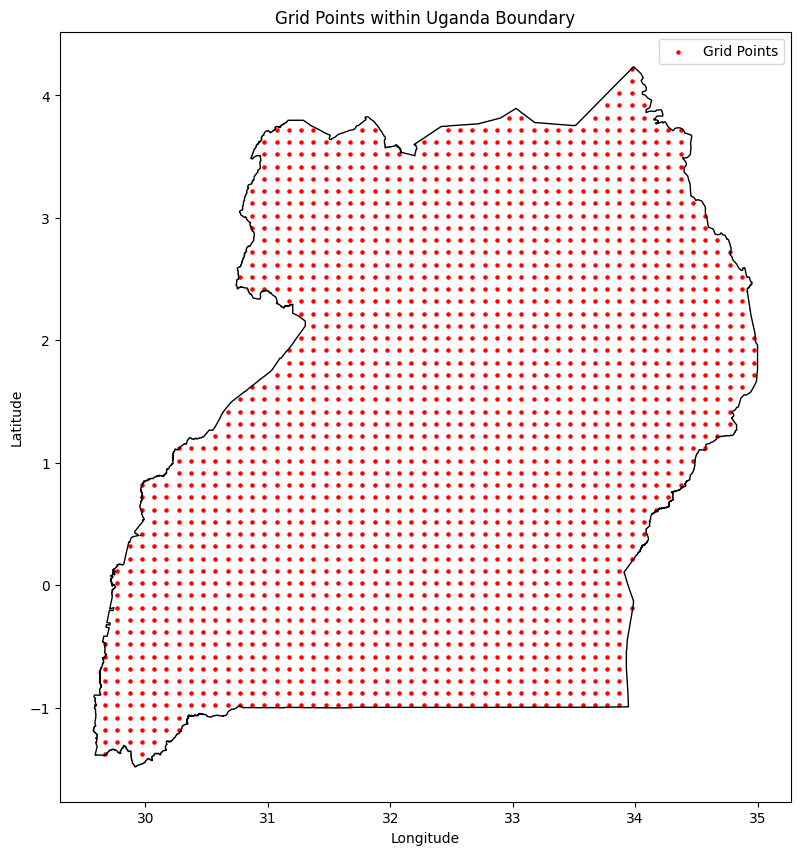

In [3]:
import matplotlib.pyplot as plt

# plot the Uganda map indicating the grid points
fig, ax = plt.subplots(figsize=(10, 10))
uganda_map.boundary.plot(ax=ax, color='black', linewidth=1)
grid_gdf.plot(ax=ax, color='red', markersize=5, label='Grid Points')
plt.title('Grid Points within Uganda Boundary')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()

## Download NASA POWER Data

The following cell will download data for each grid point:
- Checks if data for a coordinate has already been downloaded
- Downloads multiple parameters from NASA POWER
- Saves data to a CSV file
- Includes a 60-second cooldown between requests

> **Note**: The process may take several hours to complete
> 
> **Tip**: You can safely interrupt the download at any time by pressing `Ctrl+C`. 
> Your progress will be saved, and you can resume from where you left off later.

In [6]:
# Set up output file
csv_filename = "downloaded_data/NASA_power_ug_data.csv"
existing_coordinates, first_write = check_existing_coordinates(csv_filename)

# print(f"Download period: {start_date.date()} to {end_date.date()}")
# print(f"Downloading products: {[p.name for p in products_to_download]}")
print(f"Press Ctrl+C at any time to safely stop the download process")
print("-" * 40)

# Loop through each grid point and download data
skipped_count = 0
processed_count = 0

try:
    for i, point in enumerate(uganda_coordinates):
        lon, lat = point
        
        # Check if coordinate has already been processed
        if should_skip_coordinate(lat, lon, existing_coordinates):
            skipped_count += 1
            print(f"\nSkipping grid point {i+1}/{len(uganda_coordinates)}: (Lat={lat:.2f}, Lon={lon:.2f}) - Already downloaded")
            continue
        
        processed_count += 1
        print(f"\nProcessing grid point {i+1}/{len(uganda_coordinates)}: (Lat={lat:.2f}, Lon={lon:.2f})")

        location = GeoPoint(latitude=lat, longitude=lon)

        try:
            # Fetch data from NASA POWER
            multi_result = fetcher.fetch_multiple_parameters(
                temporal_resolution=temporal_res,
                start_date=start_date,
                end_date=end_date,
                location=location,
                products=products_to_download,
            )

            # Process and save the data
            df = multi_result.to_dataframe()
            df['latitude'] = lat
            df['longitude'] = lon
            
            # Reorder columns to put coordinates first
            cols = ['latitude', 'longitude'] + [p.name for p in products_to_download]
            df = df.reindex(columns=cols)
            
            # Save to CSV
            df.to_csv(csv_filename, mode='a', header=first_write, index=True)
            add_coordinate_to_existing(lat, lon, existing_coordinates)
            first_write = False

            print(f"  ✓ Success! Converted result to DataFrame with {len(df)} rows and wrote to {csv_filename}.")

        except requests.exceptions.HTTPError as http_err:
            print(f"  ✗ FAILED. HTTP Error: {http_err}")
        except Exception as e:
            print(f"  ✗ FAILED. An unexpected error occurred: {e}")

        # Add a cooldown between requests if not the last point
        if i < len(uganda_coordinates) - 1:
            # print(f"Cooling down for {API_COOLDOWN} seconds...")
            time.sleep(API_COOLDOWN)

except KeyboardInterrupt:
    print("\n\n📋 Download process interrupted by user")
    print("Don't worry - your progress has been saved!")
    print(f"You can restart the notebook later to continue from where you left off")

finally:
    # Print summary
    print("\n" + "="*40)
    print_download_summary(skipped_count, processed_count, csv_filename)
    show_data_preview(csv_filename, first_write)

d:\Github\Solar_irradiation\scripts\data_download_for_heatmap\download_utils.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  existing_df = pd.read_csv(csv_filename)


Found existing CSV file with 279 unique coordinate pairs already downloaded.
Press Ctrl+C at any time to safely stop the download process
----------------------------------------

Skipping grid point 1/1962: (Lat=-1.38, Lon=29.67) - Already downloaded

Skipping grid point 2/1962: (Lat=-1.38, Lon=29.97) - Already downloaded

Skipping grid point 3/1962: (Lat=-1.28, Lon=29.67) - Already downloaded

Skipping grid point 4/1962: (Lat=-1.28, Lon=29.77) - Already downloaded

Skipping grid point 5/1962: (Lat=-1.28, Lon=29.87) - Already downloaded

Skipping grid point 6/1962: (Lat=-1.28, Lon=29.97) - Already downloaded

Skipping grid point 7/1962: (Lat=-1.28, Lon=30.07) - Already downloaded

Skipping grid point 8/1962: (Lat=-1.18, Lon=29.67) - Already downloaded

Skipping grid point 9/1962: (Lat=-1.18, Lon=29.77) - Already downloaded

Skipping grid point 10/1962: (Lat=-1.18, Lon=29.87) - Already downloaded

Skipping grid point 11/1962: (Lat=-1.18, Lon=29.97) - Already downloaded

Skipping grid p

d:\Github\Solar_irradiation\scripts\data_download_for_heatmap\download_utils.py:112: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  preview_df = pd.read_csv(csv_filename)
